In [ ]:
%load_ext autoreload
%autoreload 2

import os
os.environ['MUJOCO_GL'] = 'egl'

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score
import sys

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2')
sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
#from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

In [3]:
from common.latent_projector import LatentProjector
from common.nonlinear_latent_projector import NonlinearLatentProjector
from projected_tdmpc2 import ProjectedTDMPC2

In [4]:
from analysis.utils import load_sweep_metadata, load_data

CKPT_TO_USE = 500_000
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

df['ckpt_int'] = df['checkpoint'].apply(
    lambda x: int(x.split('/')[-1].split('.')[0]))
# df['angle_degrees'] = df['initial_state'].apply(lambda x: np.degrees(x[1]))
# #df = df[~df['angle_degrees'].isin([0.0, 360.0])]

df = df[df['ckpt_int'] == CKPT_TO_USE]
z = np.concatenate(df['latent_states'].tolist())
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/26-01-04-cartpole_swingup-model_sweep: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 7842.67it/s]


Found 108 configurations
Found 108 configurations


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 208.60it/s]


In [6]:
z_torch = torch.from_numpy(z.copy())
obs_torch = torch.from_numpy(obs.copy())

In [ ]:
save_directory = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-22-cartpole_swingup-projected_sweep'

# PCA
for k in [8, 9, 10, 11, 12, 13, 14, 15]:
    projector = LatentProjector.fit(
        z_torch,
        k=k,
        method='pca',
    )
    path = f"{save_directory}/pca_projector_k{k}.pt"
    projector.save(path)
    print(f"Saved PCA projector with k={k} to {path}")

# Hybrid CCA: 5 state-predictive directions
for k_unsupervised in [4, 5, 6, 7, 8, 9, 10]:
    k_supervised = 5
    projector = LatentProjector.fit(z_torch,
                                    k=k_unsupervised + k_supervised,
                                    method='hybrid_ols',
                                    states=obs_torch,
                                    k_supervised=k_supervised,
                                    ridge=1e-4)
    path = f"{save_directory}/hybrid_ols_projector_k{k_unsupervised}_k_supervised{k_supervised}.pt"
    projector.save(path)
    print(
        f"Saved hybrid OLS projector with k_unsupervised={k_unsupervised} and k_supervised={k_supervised} to {path}"
    )

# Supervised CCA
projector = LatentProjector.fit(z_torch,
                                k=5,
                                method='cca',
                                states=obs_torch,
                                k_supervised=5,
                                ridge=1e-4)
projector.save(f"{save_directory}/cca_projector_k5.pt")
print(f"Saved CCA projector with k=5 to {save_directory}/cca_projector_k5.pt")

train_latents = z_torch[:6000]
test_latents = z_torch[6000:]
for k in [3, 4, 5, 6, 7, 8, 10, 15]:
    print(f"\n=== Fitting NonlinearLatentProjector with k={k} ===")
    projector = NonlinearLatentProjector.fit(
        train_latents,
        test_latents,
        k=k,
        epochs=1000,
        early_stopping_patience=100,
    )
    path = f"{save_directory}/nonlinear_projector_k{k}.pt"
    projector.save(path)
    print(f"Saved nonlinear projector with k={k} to {path}")



=== Fitting NonlinearLatentProjector with k=2 ===


Fitting k=2:  68%|██████▊   | 681/1000 [02:08<01:00,  5.30it/s, test=0.230981, train=0.201734]



Early stopping at epoch 682
NonlinearLatentProjector.fit: k=2, train_R²=0.7995, test_R²=0.7725 (N_train=30000, N_test=20000)
NonlinearLatentProjector saved to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-22-cartpole_swingup-projected_sweep/nonlinear_projector_k2.pt
Saved nonlinear projector with k=2 to /home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/26-01-22-cartpole_swingup-projected_sweep/nonlinear_projector_k2.pt


## Agent performance

In [13]:
# Base configuration for state-based environment

CKPT_PATH_STATE = f'../logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'

override_cfg_state = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH_STATE,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,
    record_planning=False,
)

# Create state-based environment
with initialize(config_path="../tdmpc2", version_base=None):
    cfg_state = compose(config_name="config")
    OmegaConf.set_struct(cfg_state, False)
    cfg_state = OmegaConf.merge(cfg_state, override_cfg_state)

cfg_state = parse_cfg(cfg_state)
set_seed(cfg_state.seed)

cfg_state.initial_state = {
    'qpos': {
        'slider': 0,
        'hinge_1': 0,
    },
}

env_state = make_env(cfg_state)

print("\nLoading state-based agent...")
agent_state = ProjectedTDMPC2(cfg_state, projector)
if hasattr(cfg_state, 'checkpoint') and cfg_state.checkpoint:
    print(f"Loading checkpoint: {cfg_state.checkpoint}")
    agent_state.load(cfg_state.checkpoint)



Loading state-based agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: ../logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [14]:
# # Use normally - projection is applied after encoding
# action = agent_state.act(torch.from_numpy(obs[0, :]), t0=True, eval_mode=True)

# # For analysis: get both raw and projected latents
# z_raw, z_proj = agent_state.encode_and_project(torch.from_numpy(obs[0, :]))
# plt.plot(z_raw.T.detach().cpu().numpy())
# plt.plot(z_proj.T.detach().cpu().numpy())

In [15]:
def evaluate_agent(agent, env, num_episodes=5):
    """
    Evaluate agent on environment.
    
    Returns:
        dict with episode rewards, lengths, and success rates
    """
    ep_rewards = []
    ep_lengths = []
    ep_successes = []
    observations = []
    for ep in tqdm(range(num_episodes), desc="Evaluating"):
        observations_episode = []
        obs = env.reset(initial_state={
            'qpos': {
                'slider': 0,
                'hinge_1': np.radians(180),
            },
        })
        observations_episode.append(obs.numpy())
        done = False
        ep_reward = 0
        t = 0

        for _ in tqdm(range(500)):
            obs_tensor = torch.from_numpy(obs).float() if isinstance(
                obs, np.ndarray) else obs
            action = agent.act(obs_tensor, t0=(t == 0), eval_mode=True)
            obs, reward, done, info = env.step(action)
            ep_reward += reward
            t += 1
            observations_episode.append(obs.numpy())

        observations.append(observations_episode)
        ep_rewards.append(ep_reward)
        ep_lengths.append(t)
        ep_successes.append(info.get('success', 0))

    results = {
        'rewards': ep_rewards,
        'lengths': ep_lengths,
        'successes': ep_successes,
        'mean_reward': np.mean(ep_rewards),
        'std_reward': np.std(ep_rewards),
        'mean_length': np.mean(ep_lengths),
        'success_rate': np.mean(ep_successes),
        'observations': observations,
    }

    print(f"\nResults over {num_episodes} episodes:")
    print(
        f"  Mean reward: {results['mean_reward']:.2f} ± {results['std_reward']:.2f}"
    )
    print(f"  Mean length: {results['mean_length']:.1f}")
    print(f"  Success rate: {results['success_rate']:.2%}")

    return results


# Run evaluation
results = evaluate_agent(agent_state, env_state, num_episodes=1)

Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:11<00:00, 11.74s/it]


Results over 1 episodes:
  Mean reward: 881.75 ± 0.00
  Mean length: 500.0
  Success rate: 0.00%


In [16]:
from analysis.utils import reconstruct_cartpole_dmcontrol

obs_episode = np.array(results['observations'][0])
reconstruct_cartpole_dmcontrol(obs_episode, show=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 501/501 [00:00<00:00, 527.20it/s]


In [17]:
z_proj, h = projector.project_and_components(torch.from_numpy(z).to('cuda'))
h.shape

torch.Size([9000, 6])

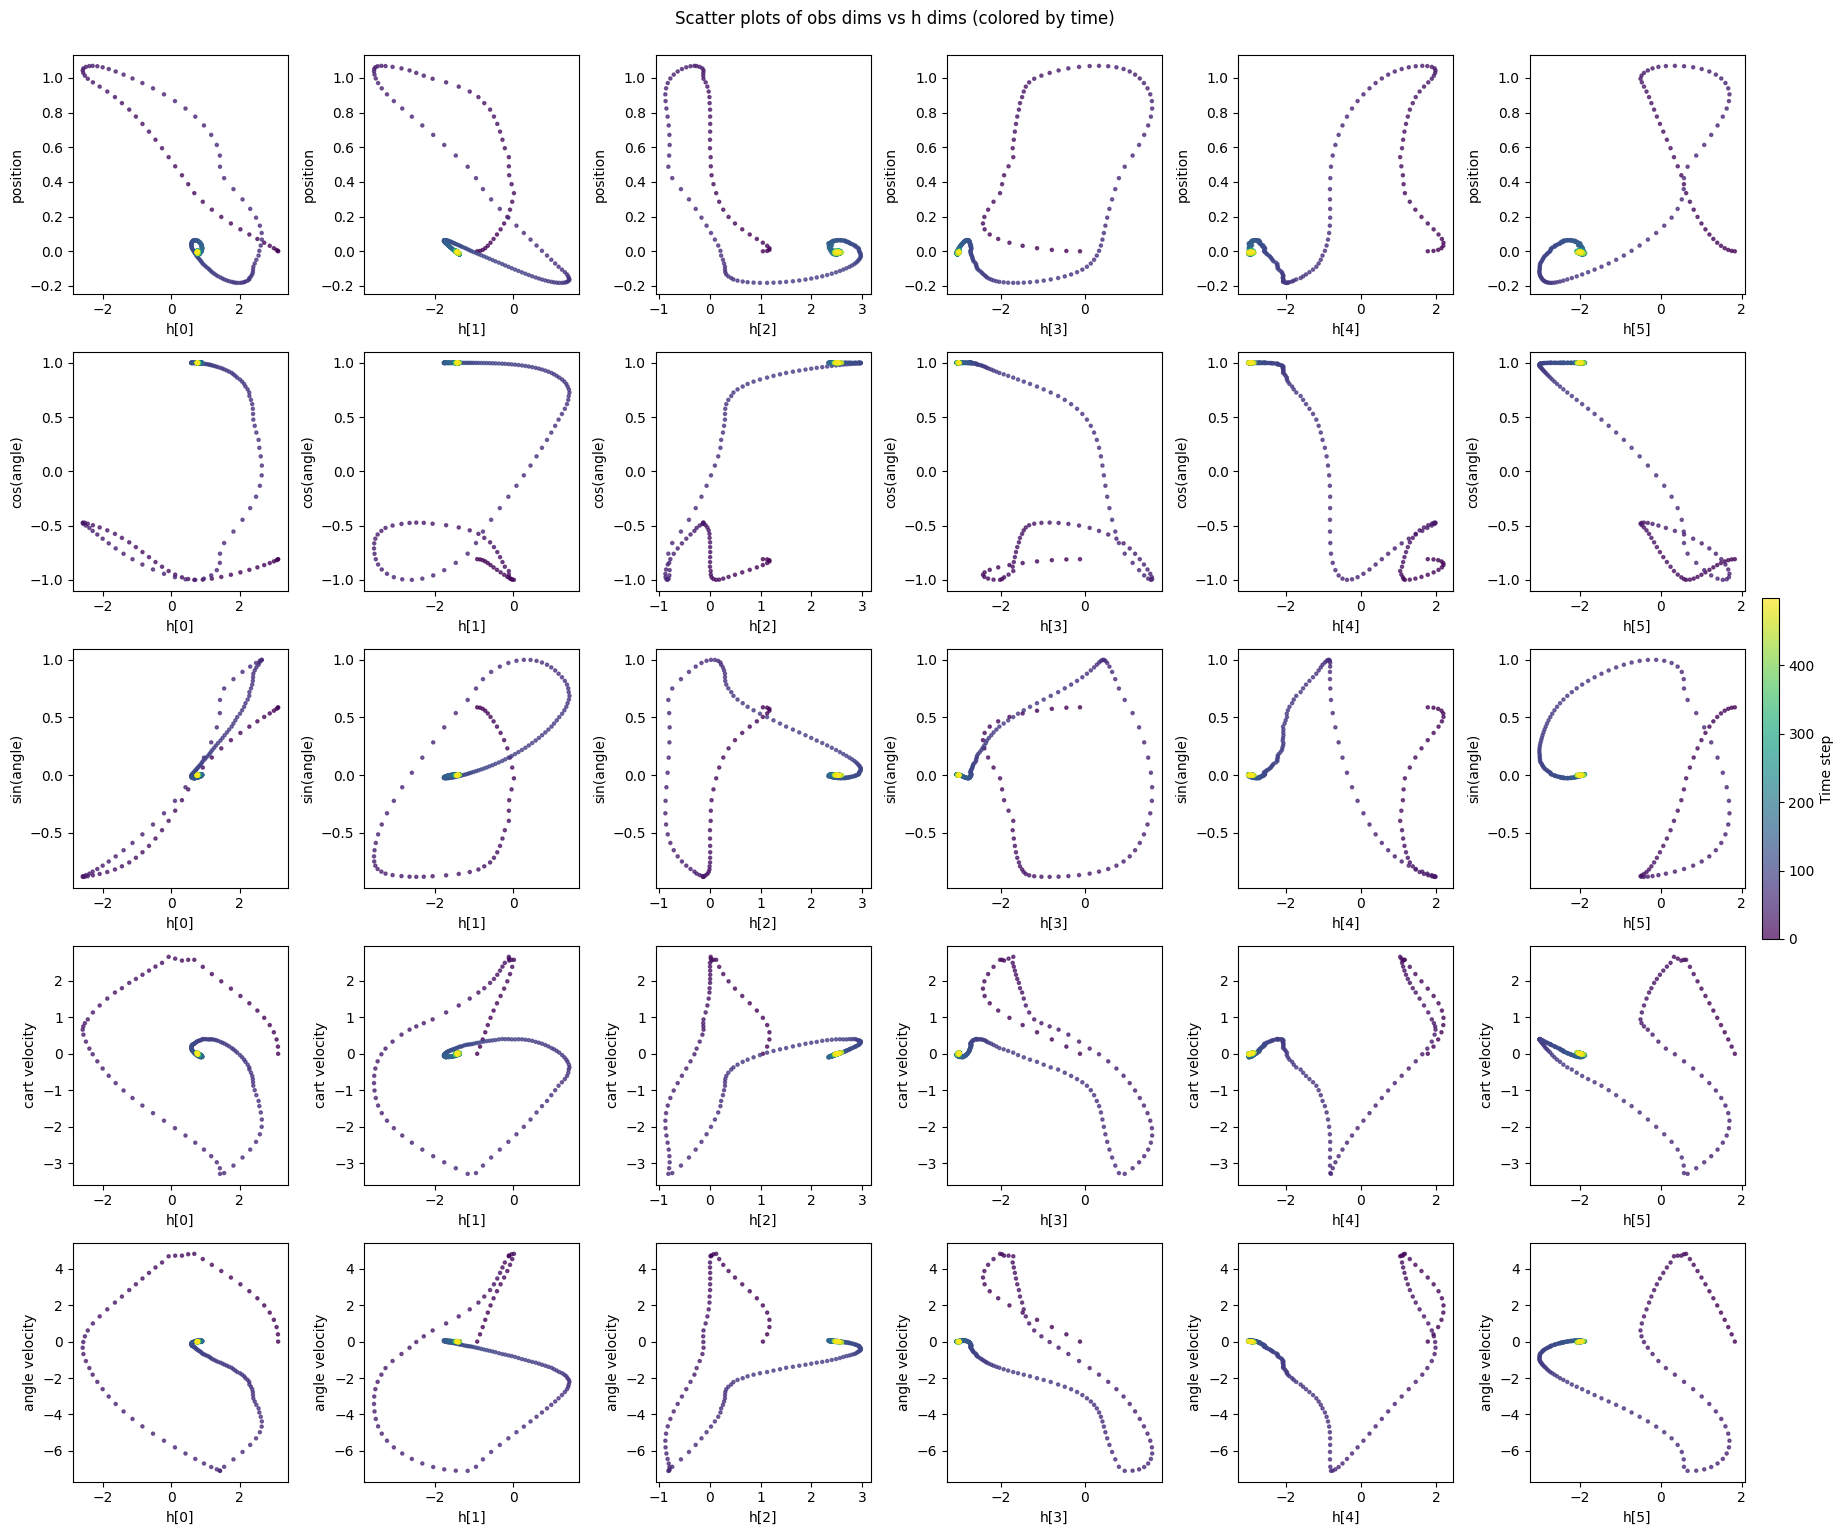

In [26]:
import matplotlib.pyplot as plt

obs_variable_names = {
    0: 'position',
    1: 'cos(angle)',
    2: 'sin(angle)',
    3: 'cart velocity',
    4: 'angle velocity'
}

episode = 4
obs_plot = obs[episode * 500:(episode + 1) * 500]
h_plot = h[episode * 500:(episode + 1) * 500]

num_obs_dim = obs_plot.shape[1]
num_h_dim = h_plot.shape[1]

# We'll color points by time
cmap = plt.get_cmap("viridis")
times = np.arange(obs_plot.shape[0])

plt.figure(figsize=(3 * num_h_dim, 3 * num_obs_dim))

for i in range(num_obs_dim):
    for j in range(num_h_dim):
        plt.subplot(num_obs_dim, num_h_dim, i * num_h_dim + j + 1)
        x = h_plot[:, j].cpu() if hasattr(h_plot[:, j], 'cpu') else h_plot[:, j]
        y = obs_plot[:, i]
        sc = plt.scatter(x, y, c=times, cmap=cmap, s=5, alpha=0.7)
        plt.xlabel(f'h[{j}]')
        plt.ylabel(f'{obs_variable_names[i]}')
        plt.tight_layout()

plt.suptitle("Scatter plots of obs dims vs h dims (colored by time)", y=1.02)
cbar = plt.colorbar(sc,
                    ax=plt.gcf().get_axes(),
                    orientation='vertical',
                    fraction=0.01,
                    pad=0.01)
cbar.set_label('Time step')
plt.show()

## Decoding analysis

In [39]:
# Compare projected vs original
z_proj = projector(torch.from_numpy(z).to('cuda')).detach().cpu().numpy()
residual = z - z_proj  # What's being lost?

# # Decode residual to state - is it correlated with anything important?
from sklearn.linear_model import Ridge

decoder = Ridge().fit(residual, obs[:, 4])
print(f"Residual → State R²: {decoder.score(residual, obs[:, 4])}")

Residual → State R²: 1.150369644165039e-05


In [ ]:
residual

array([[-2.91142613e-03,  1.27552450e-03,  4.28214669e-03, ...,
        -2.01400742e-03,  7.24746846e-04,  3.08835879e-03],
       [-8.78117979e-04,  3.28645110e-04, -3.80218029e-04, ...,
        -7.83428550e-06,  2.08174810e-04,  2.00589746e-03],
       [ 4.23759222e-04, -4.86701727e-04, -1.24710798e-03, ...,
         1.80044025e-03,  2.70877033e-04, -3.43546271e-04],
       ...,
       [-4.34443355e-05, -2.31713057e-05, -5.48809767e-05, ...,
         3.47793102e-05,  1.45845115e-05, -1.62161887e-05],
       [-3.67313623e-05, -4.95463610e-06, -2.00644135e-05, ...,
         1.37984753e-05,  8.76560807e-06, -2.10516155e-05],
       [-5.26979566e-05, -7.89090991e-05, -1.58816576e-04, ...,
         8.74102116e-05,  3.32407653e-05,  9.52929258e-06]], dtype=float32)

In [ ]:
results_state = {}
results_pca = {}
for dim in range(5):
    obs_dim = obs[:, dim]
    results_state_ = evaluate_lags_leave_k_out(chunk_data(z_state),
                                               chunk_data(obs_dim),
                                               np.arange(-40, 41, 10),
                                               k_holdout=1,
                                               model='linear_regression',
                                               add_bootstrap_ci=True)

    results_pca_ = evaluate_lags_leave_k_out(chunk_data(z_pca),
                                             chunk_data(obs_dim),
                                             np.arange(-40, 41, 10),
                                             k_holdout=1,
                                             model='linear_regression',
                                             add_bootstrap_ci=True)

    results_state[dim] = results_state_
    results_pca[dim] = results_pca_